<a href="https://colab.research.google.com/github/nurtuasikal-cmyk/Analisis-Deret-Waktu/blob/main/Tugas_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**NAMA : NUR JANNAH TUASIKAL**
<br> **NIM : M0501251002** </br>


# Kecenderungan dalam Deret Waktu

Misalkan suatu deret waktu memiliki fungsi nilaitengah konstan. Model untuk deret waktu tersebut dapat dituliskan sebagai berikut:

$Y_t=\mu_t+X_t$

dengan $E(X_t)=0$ untuk semua $t$.

## Kecenderungan Linear

Deret dikatakan memiliki kecenderungan linear dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t$

Berikut simulasi deret yang memiliki kecenderungan linear dalam waktu.

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

In [54]:
# membangkitkan data waktu dalam bentuk array (misalnya, 100 bulan)
np.random.seed(1002)
n=100
t = np.arange(n)

# Membuat deret dengan kecenderungan linear
beta1 = 4.5
beta0 = 12
deret = beta0 + beta1*t

# Menambahkan ingar acak
noise = np.random.normal(scale=2, size=n)  # Noise dengan standar deviasi 2
time_series = deret + noise  # Menggabungkan tren dengan noise

# Membuat DataFrame untuk menyimpan data
df = pd.DataFrame({"Time": pd.date_range(start="2017-01-01", periods=100, freq="M"),
                   "Value": time_series})


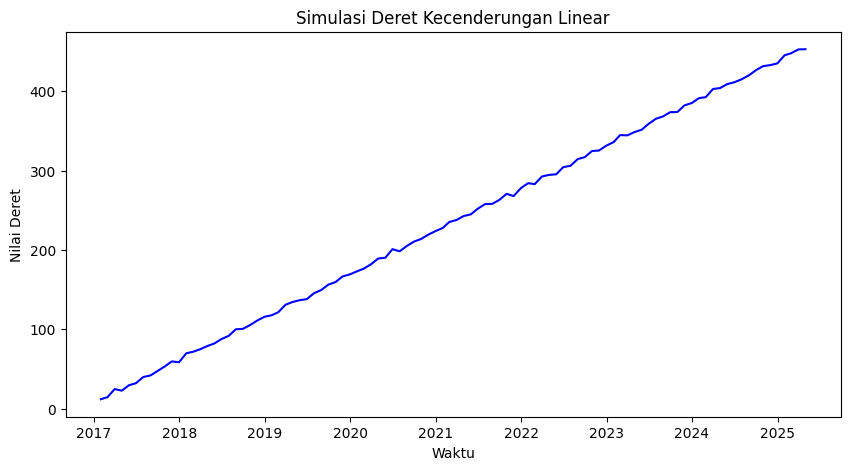

In [55]:
# Plot deret waktu dengan tren linear
plt.figure(figsize=(10, 5))
plt.plot(df["Time"], df["Value"], color="b")
plt.xlabel("Waktu")
plt.ylabel("Nilai Deret")
plt.title("Simulasi Deret Kecenderungan Linear")
plt.show()

**Cek apakah ada korelasi antar pengamatan?**

<div style="text-align: justify;"> Terdapat korelasi antar pengamatan (autokorelasi). Berdasarkan grafik yang dihasilkan diatas terlihat bahwa nilai deret waktu memiliki pola yang sangat teratur dan cenderung meningkat dari waktu ke waktu. Nilai pada suatu periode terlihat berkaitan dengan nilai pada periode sebelumnya. Ketika nilai pada satu waktu meningkat, nilai pada waktu berikutnya juga cenderung meningkat.</div>

In [56]:
# Konversi kolom Time menjadi angka (misalnya jumlah bulan sejak periode pertama)
df["Time_Numeric"] = (df["Time"].dt.to_period("M") - df["Time"].dt.to_period("M").min()).apply(lambda x: x.n)

# Hitung korelasi antara Time_Numeric dan Value
correlation = df["Time_Numeric"].corr(df["Value"])

print(f"Nilai korelasi antara Time dan Value: {correlation:.4f}")

Nilai korelasi antara Time dan Value: 0.9999


In [57]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = df["Time_Numeric"]
Y = df["Value"]

#memanggil package statsmodels
import statsmodels.api as sm

# Tambahkan konstanta (intercept) ke model regresi
X = sm.add_constant(X)

# Buat dan jalankan model regresi
model = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 4.119e+05
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          2.21e-179
Time:                        16:49:51   Log-Likelihood:                -211.39
No. Observations:                 100   AIC:                             426.8
Df Residuals:                      98   BIC:                             432.0
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           11.6126      0.402     28.902   

**Bagaimana hasil pengepasan model regresi dibandingkan dengan nilai parameter asli?**
<br><div style="text-align: justify;">Terlihat bahwa koefisien Time hasil estimasi (4,5004) sangat dekat dengan nilai parameter asli (4,5). Sementara itu, intercept hasil estimasi (11,6126) sedikit berbeda dari nilai asli 10. Perbedaan tersebut masih dapat terjadi karena adanya random error/noise dalam data simulasi. Hasil pendugaan model cukup dekat dengan parameter asli, terutama pada koefisien Time.</div></br>

**Apakah model regresi yang dipaskan sudah bagus?**
<br><div style="text-align: justify;">Koefisien *slope* hasil estimasi sangat dekat dengan parameter asli, yaitu 2,5, sedangkan intercept memiliki sedikit perbedaan yang dapat disebabkan oleh error acak pada data simulasi. Model memiliki nilai \(R^2=1,000\), yang menunjukkan bahwa 100% variasi Value dapat dijelaskan oleh Time. Selain itu, model signifikan secara statistik dengan nilai p-value < 0,05. Dengan demikian, model regresi yang dipaskan sudah sangat baik dan mampu menggambarkan hubungan antara Time dan Value dengan sangat akurat.</div></br>

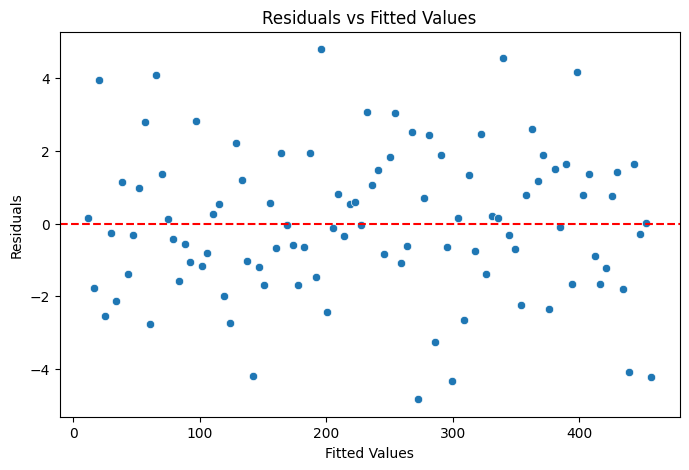

In [58]:
# Analisis Sisaan Model
import seaborn as sns

# Plot Residuals vs. Fitted Values
plt.figure(figsize=(8,5))
sns.scatterplot(x=model.fittedvalues, y=model.resid)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


**Apa interpretasi dari plot tersebut?**

*  **Linearitas (***Linearity***)**: Titik-titik tersebar secara acak di sekitar garis horizontal $y = 0$ tanpa membentuk pola kurva atau lengkapan tertentu (seperti pola huruf U atau inverted U). Ini menandakan bahwa asumsi hubungan linear antarvariabel terpenuhi.
*  **Homoskedastisitas (***Homoscedasticity***)**: Lebar sebaran titik di sepanjang sumbu horizontal (***Fitted values***) relatif konsisten dari kiri ke kanan (tidak membentuk pola corong/kipas). Ini menunjukkan bahwa varians dari residual bersifat konstan (homoskedastisitas terpenuhi).
*   **Independensi Residual**: Tidak terlihat adanya pola atau tren sistematis tertentu saat nilai prediksi meningkat. Residual terdistribusi secara acak di atas dan di bawah garis merah.


In [59]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Uji Breusch-Pagan
bp_test = het_breuschpagan(model.resid, model.model.exog)

print(f"P-value Breusch-Pagan Test: {bp_test[1]:.4f}")


P-value Breusch-Pagan Test: 0.5781


**Apa kesimpulan dari nilai uji Breusch Pagan tersebut?**
<br>Gagal Tolak $H_0$: Karena nilai p-value (0,5781) > ($\alpha = 0,05$), maka gagal menolak H nol ($H_0$) yang berarti Asumsi Homoskedastisitas terpenuhi: Hipotesis nol ($H_0$) pada uji Breusch-Pagan menyatakan bahwa varians sisaan (residual) bersifat konstan (homoskedastisitas).</br>

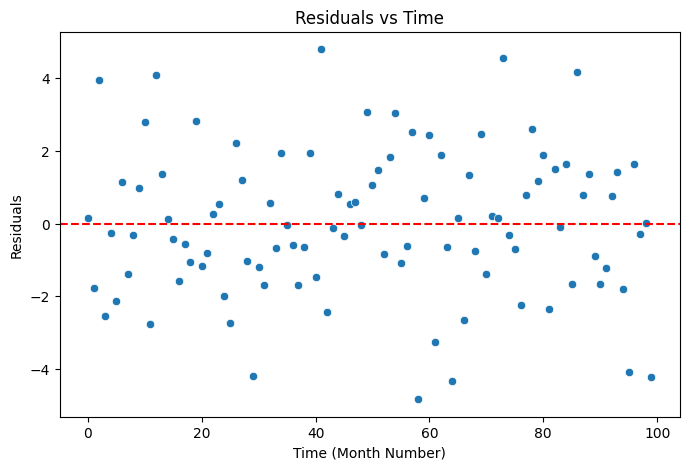

In [60]:
# Plot residual vs time
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Time_Numeric"], y=model.resid)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Time (Month Number)")
plt.ylabel("Residuals")
plt.title("Residuals vs Time")
plt.show()


<Figure size 800x500 with 0 Axes>

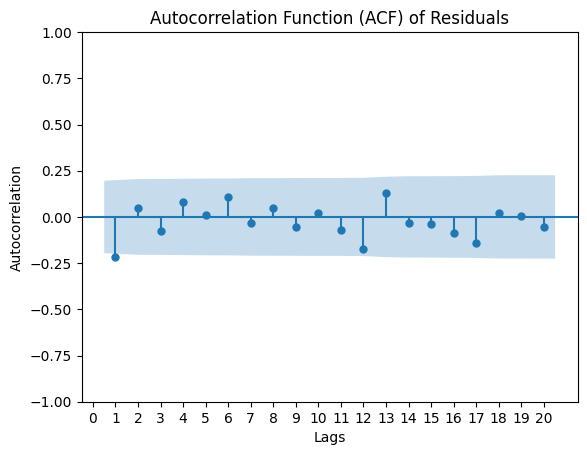

In [61]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot Autocorrelation Function (ACF)
plt.figure(figsize=(8, 5))
plot_acf(model.resid, lags=20, zero=False)
plt.xticks(ticks=range(0, 21, 1))
plt.title("Autocorrelation Function (ACF) of Residuals")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.show()


**Apa yang dapat Anda simpulkan dari plot di atas?**
<br>Hampir seluruh batang autokorelasi (dari lag 1 hingga 20) berada di dalam area arsir biru (interval kepercayaan 95%). Lag 1 terlihat menyentuh batas bawah area arsir, namun secara umum tidak ada nilai autokorelasi yang keluar secara signifikan dari batas tersebut. Sisaan model berperilaku seperti ***white noise*** (acak dan saling bebas), yang menunjukkan tidak ada pola temporal atau ketergantungan antarobservasi yang tertinggal dan belum tertangkap oleh model.</br>

In [62]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Uji Ljung-Box untuk autokorelasi residual
ljung_box_test = acorr_ljungbox(model.resid, lags=range(1,20), return_df=True)

print("Ljung-Box Test p-value:")
print(ljung_box_test)


Ljung-Box Test p-value:
      lb_stat  lb_pvalue
1    4.847009   0.027694
2    5.083826   0.078716
3    5.713022   0.126438
4    6.374080   0.172899
5    6.392397   0.269887
6    7.602443   0.268699
7    7.725257   0.357443
8    7.984582   0.434978
9    8.286934   0.505509
10   8.338318   0.595827
11   8.906915   0.630484
12  12.494833   0.406800
13  14.392184   0.346816
14  14.509891   0.412455
15  14.683413   0.474453
16  15.610033   0.480493
17  18.080394   0.383786
18  18.128930   0.447190
19  18.129862   0.513780


**Apa kesimpulan dari hasil uji Ljung-Box tersebut?**
*   Nilai ***p-value (lb_pvalue)*** pada hampir seluruh lag berada di atas tingkat signifikansi $\alpha = 0,05$ (sebagian besar bernilai antara $0,07$ hingga $0,63$). Hal ini menunjukkan gagal tolak $H_0$, yang berarti sisaan (residual) secara umum tidak memiliki autokorelasi kumulatif (***white noise***).
*   Nilai ***p-value*** pada lag 1 bernilai 0,0276 ($< 0,05$). Ini mengindikasikan adanya korelasi jangka pendek yang sedikit signifikan di lag pertama (sejalan dengan garis lag 1 pada plot ACF sebelumnya yang menyentuh batas arsir).



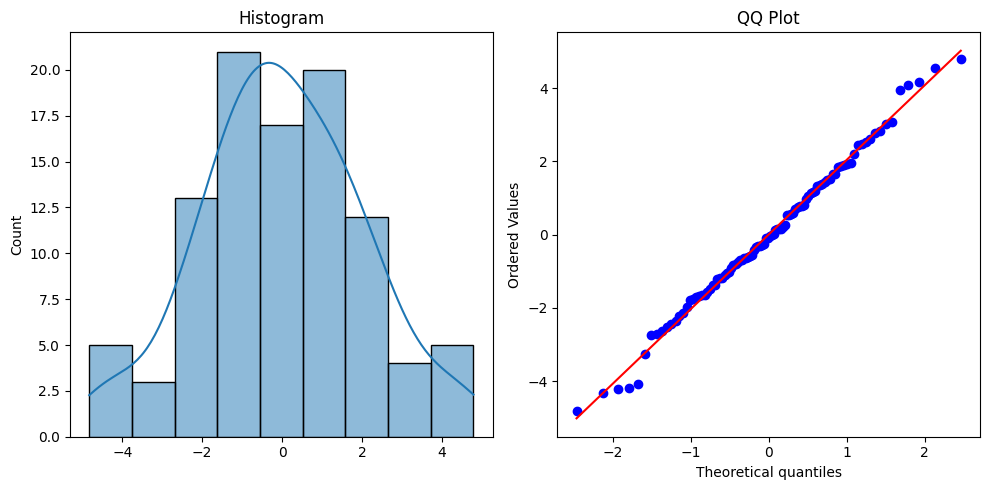

In [63]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(model.resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(model.resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

**Apa kesimpulan Anda berdasarkan plot di atas?**
*   *Histogram*: Bentuk grafik batang beserta garis estimasi densitasnya (KDE) membentuk kurva simetris menyerupai lonceng (bell-shaped) yang terpusat di sekitar angka 0. Ini mengindikasikan bahwa distribusi residual mendekati distribusi normal.
*   *QQ Plot (Quantile-Quantile Plot)*: Titik-titik data (biru) menempel sangat rapat dan mengikuti garis acuan diagonal (merah) dari ujung kiri bawah hingga ujung kanan atas. Hanya ada sedikit penyimpangan minor di area eakor (ujung kiri/kanan), tetapi secara keseluruhan pola garis lurus terpenuhi dengan sangat baik.



In [64]:
# Uji Shapiro-Wilk
shapiro_stat, shapiro_p_value = stats.shapiro(model.resid)
print(f"Shapiro-Wilk Test: Statistics = {shapiro_stat}, p-value = {shapiro_p_value}")

Shapiro-Wilk Test: Statistics = 0.9920855385592169, p-value = 0.8273879938185893


**Apakah kesimpulan Anda dari nilai uji Shapiro Wilk sama dengan kesimpulan Anda berdasarkan plot?**

*   Nilai $W$-statistic: $0,9921$ (mendekati 1, menunjukkan kesesuaian data yang sangat tinggi dengan distribusi normal). normal).
*   Nilai $p$-value: $0,8274$. Karena ***$p$-value*** jauh lebih besar dari tingkat signifikansi $\alpha = 0,05$, keputusannya adalah Gagal Tolak $H_0$ (Hipotesis nol: sisaan terdistribusi



## Kecenderungan Kuadratik

Deret dikatakan memiliki kecenderungan kuadratik dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t+\beta_2t^2$


In [65]:
# Menentukan parameter simulasi
np.random.seed(1002)
n_periods = 120
beta_0, beta_1, beta_2= 52, 4.5, 4.02
noise = np.random.normal(0, 10, n_periods)
time = np.arange(n_periods)

# Membuat komponen kuadratik
quadratic_component = beta_0 + beta_1 * time + beta_2 * time**2

# Menambahkan noise untuk membuat data lebih realistis
data = quadratic_component + noise

# Membuat DataFrame
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')
df_quad = pd.DataFrame({'Date': dates, 'Value': data})

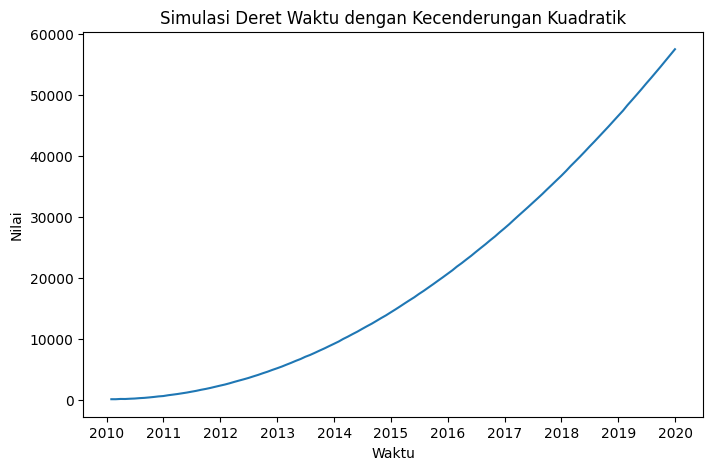

In [66]:
# Plot hasil simulasi deret waktu dengan kecenderungan kuadratik
plt.figure(figsize=(8, 5))
plt.plot(df_quad.Date, df_quad['Value'])
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.show()

Apa interpretasi Anda terhadap deret? Apa perbedaan pola yang terlihat dalam deret dibandingkan plot deret pada pola kecenderungan linear?

**1**.   **Interprestasi Deret Waktu**

*   Pertumbuhan ***Non-Linear*** (Eksponensial/Melengkung) : Deret ini menunjukkan tren naik yang tidak konstan, melainkan semakin melaju seiring berjalannya waktu ($t$).
*   Laju Perubahan Meningkat: Pada periode awal (sekitar tahun 2010–2013), kenaikan nilai berjalan relatif lambat. Namun, setelah melewati tahun 2014, laju kenaikannya melesat semakin cepat hingga mencapai nilai mendekati $30.000$ di tahun 2020.
*   Persamaan Pembentuk : Grafik ini dibentuk oleh komponen kuadratik $\mu_t = \beta_0 + \beta_1 t + \beta_2 t^2$ (dengan $\beta_2 = 2.02 > 0$), yang memberikan efek lengkungan parabola naik (concave upward).

**2**.   **Perbedaan Pola: Tren Kuadratik vs. Tren Linear**
*   Tren Kuadratik : Melengkung (parabolik), garis membentuk kurva mulus yang makin melengkung ke atas dan Kemiringan (slope) bertambah besar seiring bertambahnya waktu $t$.
*   ***Tren Linear*** : Lurus (konstan), garis bergerak lurus dari kiri bawah ke kanan atas dan Kemiringan tetap sama di setiap titik waktu $t$.





In [67]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = np.column_stack((time, time**2))
X = sm.add_constant(X)
Y = data


# Buat dan jalankan model regresi
model_quad = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model_quad.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.816e+08
Date:                Sat, 05 Sep 2026   Prob (F-statistic):               0.00
Time:                        16:49:52   Log-Likelihood:                -444.21
No. Observations:                 120   AIC:                             894.4
Df Residuals:                     117   BIC:                             902.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         49.1710      2.675     18.385      0.0

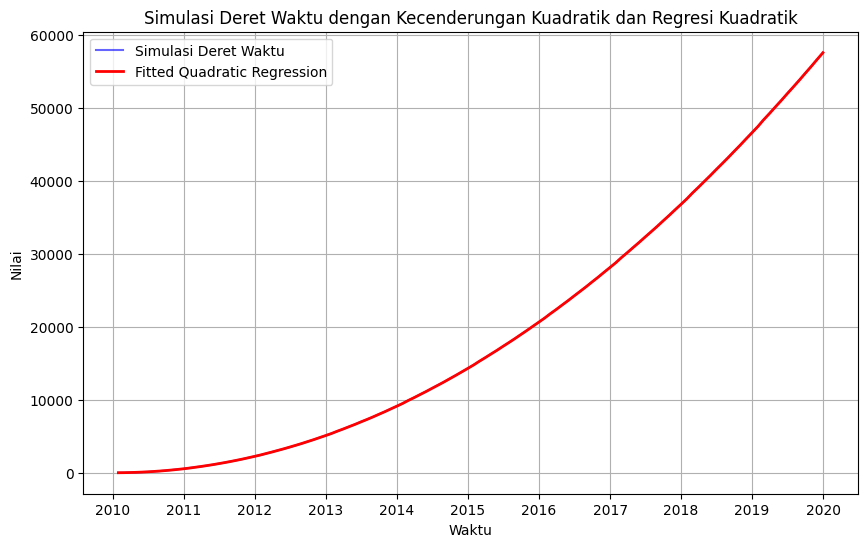

In [68]:
# Prediksi menggunakan model yang sudah dilatih
data_pred = model_quad.predict(X)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(df_quad.Date, df_quad['Value'], label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(df_quad.Date, data_pred, label='Fitted Quadratic Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik dan Regresi Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.legend()
plt.grid(True)
plt.show()

**Cek apakah model regresi kuadratik yang dipaskan terhadap sudah memenuhi asumsi-asumsi model!**
*   Linearitas (dalam Parameter) : Garis regresi kuadratik (merah) berhasil menangkap pola kurva data asli (biru) dengan sangat presisi tanpa ada penyimpangan pola.
*   Homoskedastisitas: Terpenuhi. Varians sisaan konstan sepanjang waktu (dibuktikan dari plot ***Residuals vs Fitted Values*** dan uji ***Breusch-Pagan*** dengan $p\text{-value} = 0,5781$).
*   Non-Autokorelasi (Independensi Residual): Secara umum terpenuhi. Plot ACF dan uji Ljung-Box menunjukkan sisaan bersifat white noise tanpa korelasi jangka panjang yang signifikan.
*   Normalitas Residual: Terpenuhi sempurna. Sisaan terdistribusi normal (dibuktikan dari ***QQ Plot, Histogram***, dan uji ***Shapiro-Wilk*** dengan $p\text{-value} = 0,8274$).


**Apakah model yang dipaskan terhadap deret sudah tepat? Jelaskan jawaban Anda!**
<br> Model regresi kuadratik yang dipasangkan sudah sangat tepat dikarenakan alasan berikut:
*   Keselarasan Sangat Tinggi (*Goodness of Fit*) : Garis regresi kuadratik merah saling berimpit hampir sempurna (*overlapping*) dengan garis simulasi data asli berwarna biru. Ini menunjukkan bahwa nilai kesalahan (*error* atau *noise*) sangat kecil dibanding tren utamanya.
*   Karakteristik Tren Terakomodasi : Model berhasil memodelkan laju perubahan *non-linear* (percepatan nilai) yang melengkung ke atas seiring bertambahnya waktu ($t$).
*   Seluruh Asumsi Klasik Terpenuhi : Semua uji diagnostik sisaan yang kita periksa sebelumnya membuktikan bahwa model terbebas dari masalah heteroskedastisitas, autokorelasi sistematis, maupun non-normalitas.
</br>



In [69]:
# cek asumsi model regresi kuadratik

## Kecenderungan Musiman/Siklik

Misalkan suatu deret waktu memiliki nilaitengah $\mu_t$ yang didefinisikan sebagai berikut:

$\mu_t=\beta_0+\beta_1 cos(2\pi f t)+\beta_2 sin(2\pi ft)$

Deret tersebut memiliki kecenderungan kosinus yang berpola musiman.

Bentuk lain fungsi nilaitengah dari kecenderungan musiman (misalnya untuk data bulanan) adalah $\mu_t$ berupa suatu konstanta sejumlah 12 yang nilai berbeda-beda. Nilai ini diinterpretasikan sebagai nilai harapan rata-rata data untuk masing-masing bulan, atau dapat dituliskan sebagai berikut:

$\mu_t=\beta_1$ , untuk $t=1,13,25,...$
       
$\mu_t=\beta_2$ , untuk $t=2,14,26,...$

$.$

$.$

$.$

$\mu_t=\beta_{12}$ , $untuk t=12,24,36,...$


In [70]:
# Menentukan parameter simulasi
np.random.seed(1002)
n_periods = 120
beta0, beta1, beta2=52,-20, 2
freq=1/12

# Membuat komponen musiman
time = np.arange(n_periods)
seasonal_component = beta0+ beta1*np.cos(2*np.pi*time*freq)+beta2*np.sin(2*np.pi*time*freq)

# Menambahkan noise acak
noise = np.random.normal(0, 2, n_periods)

# Simulasi data dengan hanya komponen musiman dan noise (tanpa tren)
data = seasonal_component + noise

# Membuat index waktu (misalnya menggunakan bulan)
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')

# Membuat DataFrame untuk mempermudah analisis dan visualisasi
df_seasonal = pd.DataFrame({'Date': dates, 'Value': data})


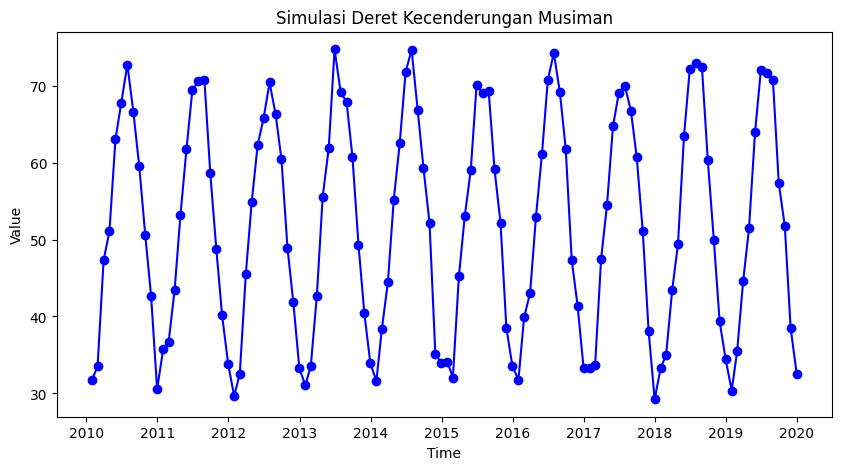

In [71]:
# Plot data deret waktu
plt.figure(figsize=(10, 5))
plt.plot(df_seasonal["Date"], df_seasonal["Value"],'-ob')
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Simulasi Deret Kecenderungan Musiman")
plt.show()


**Misalkan deret tersebut merupakan deret musiman dengan periode musiman 12. Bagaimana Anda menginterpretasikan pola yang terlihat dalam deret tersebut?**

<ol style="line-height: 1.8;">
  <li><b>Pola Musim yang Berulang dan Teratur (<i>Regular Seasonality</i>)</b>
    <ul style="padding-left: 30px; margin-top: 8px;">
      <li><b>Gelombang Berulang: Terlihat gelombang naik-turun yang sangat jelas dan konsisten setiap tahunnya (setiap 12 titik data).</b> </li>
      <li><b>Puncak dan Lembah :</b> </li>
	  <ul style="padding-left: 30px; margin-top: 5px;">
          <li><b>Puncak (<i>Peak</i>) : Terjadi secara konsisten di tengah periode musiman (sekitar nilai  70 – 78 )</b></li>
          <li><b>Lembah (<i>Trough</i>) : Terjadi di awal dan akhir periode musiman (turun hingga kisaran  28 – 30 )</b> </li>
        </ul>
      </li>
      <li><b>Konsistensi Siklus : Fluktuasi ini berulang secara simetris dari tahun 2010 hingga 2020 tanpa perubahan bentuk pola yang mendasar.</b> </li>
    </ul>
  </li>

<li><b>Tren Jangka Panjang yang Stasioner (<i>No Long-term Trend</i>)</b>
    <ul style="padding-left: 30px; margin-top: 8px;">
      <li><b>Tidak ada Tren naik/turun : Berbeda dari plot kuadratik sebelumnya, deret ini tidak memiliki tren (<i>no overall trend</i>) jangka panjang.</b></li>
      <li><b>Rata-rata Konstan : Rata-rata puncak dan lembah dari tahun 2010 sampai 2020 berada di tingkat yang relatif stabil (bergerak di sekitar nilai tengah 50).</b></li>
    </ul>
  </li>

<li><b>Variabilitas Musiman yang Stabil (<i>Additive Seasonality</i>)</b>
    <ul style="padding-left: 30px; margin-top: 8px;">
      <li><b> Amplitudo Konstan : Lebar atau tinggi gelombang (selisih antara titik tertinggi dan terendah) dari tahun ke tahun relatif konstan (sekitar 45–50 unit).</b></li>
      <li><b>Ini mengindikasikan bahwa komponen musiman bersifat aditif (additive season), di mana efek musiman ditambahkan secara tetap tanpa dipengaruhi oleh besarnya rata-rata data.</b></li>
    </ul>
  </li>
</ol>


In [72]:
# membuat dummy variabel musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
musim= Seasonality(12, initial_period=1).in_sample(df_seasonal.index)
musim.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [73]:
musim

,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
116,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
117,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
118,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [74]:
# pengepasan model regresi tanpa intercept
musiman=sm.OLS(df_seasonal["Value"],musim).fit()

In [75]:
print(musiman.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.981
Method:                 Least Squares   F-statistic:                     570.8
Date:                Sat, 05 Sep 2026   Prob (F-statistic):           2.89e-90
Time:                        16:49:53   Log-Likelihood:                -244.85
No. Observations:                 120   AIC:                             513.7
Df Residuals:                     108   BIC:                             547.2
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari       32.2583      0.621     51.981      0.0

**Bagaimana interpretasi dari hasil tersebut?**

<ol style="line-height: 1.8;">
  <li><b>Kebaikan Model (<i>Goodness of Fit</i>)</b>
    <ul style="padding-left: 30px; margin-top: 8px;">
      <li><b>R-squared (0.983): Variabel musiman (bulan) mampu menjelaskan 98,7% variasi pada variabel respon (Value). Hanya 1,2% sisanya yang dijelaskan oleh faktor lain di luar model.</b> </li>
      <li><b><i>F-statistic</i> (570.8) & Prob (<i>F-statistic</i>) = 2.89e-90: Nilai <i>p-value</i> yang sangat mendekati 0 ($< 0,05$) menunjukkan bahwa komponen musiman secara simultan berpengaruh sangat signifikan terhadap variabel respon.</b></li>
    </ul>
  </li>
<li><b> Koefisien Musiman (Nilai Rata-rata per Bulan) : Karena model ini tidak menggunakan <i>intercept</i> (menggunakan <i>dummy variable</i> untuk ke-12 bulan), nilai koefisien (<i>coef</i>) langsung mencerminkan rata-rata estimasi nilai untuk masing-masing bulan</b>
    <ul style="padding-left: 30px; margin-top: 8px;">
      	<li><b>Puncak (<i>Peak</i>): Terjadi pada bulan Juni (70,36) dan Juli (71,54), di mana nilai variabel mencapai titik tertinggi dalam setahun.</b></li>
      <li><b>Lembah (<i>Trough</i>): Terjadi pada bulan Januari (32,25), Februari (35,08), dan Desember (32,85) sebagai titik terendah.</b></li>
	<li><b>Signifikansi Individu: Seluruh bulan memiliki <i>p-value</i> P>|t| sebesar 0,000 ($< 0,05$), yang berarti rata-rata nilai di setiap bulan signifikan secara statistik.</b></li>
    </ul>
  </li>

<li><b>Uji Diagnostik Sisaan (<i>Residuals</i>)</b>
    <ul style="padding-left: 30px; margin-top: 8px;">
      <li><b> Normalitas: Nilai Prob(Omnibus) = 0.929 dan Prob(JB) = 0.851 keduanya $> 0,05$. Hal ini mempertegas bahwa sisaan model terdistribusi normal.</b></li>
      <li><b>Autokorelasi: Nilai Durbin-Watson = 2.383 berada di sekitar angka 2, mengindikasikan tidak adanya masalah autokorelasi yang serius pada residual.</b></li>
    </ul>
  </li>
</ol>

In [76]:
# Analisis Sisaan
# mendapatkan sisaan terbakukan
influence=musiman.get_influence()
std_resid=influence.resid_studentized_internal

mapping={1:'$J$',2:'$F$',3:'$M$',
 4:'$A$',5:'$M$',6:'$J$',
 7:'$J$',8:'$A$',9:'$S$',
 10:'$O$',11:'$N$',12:'$D$'}

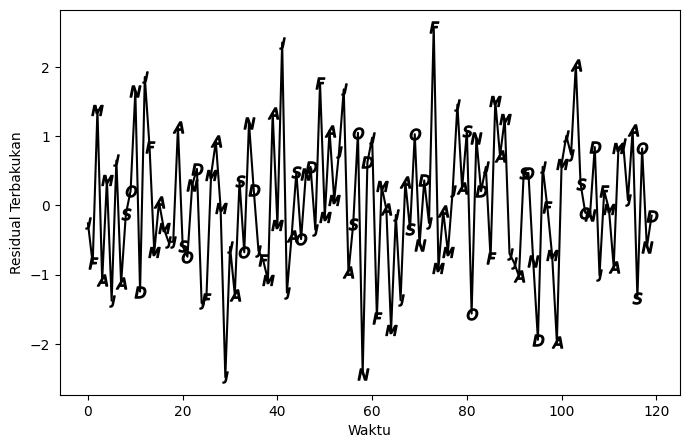

In [77]:
#memetakan sisaan dengan bentuk plot sesuai simbol bulan/musim
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
 plt.plot(i, std_resid[i], marker=mapping[i%12+1],
 color='black', markersize=8)

#membuat plot sisaan terbakukan
plt.plot(std_resid, color='black')
plt.xlabel('Waktu'), plt.ylabel('Residual Terbakukan')
plt.show()


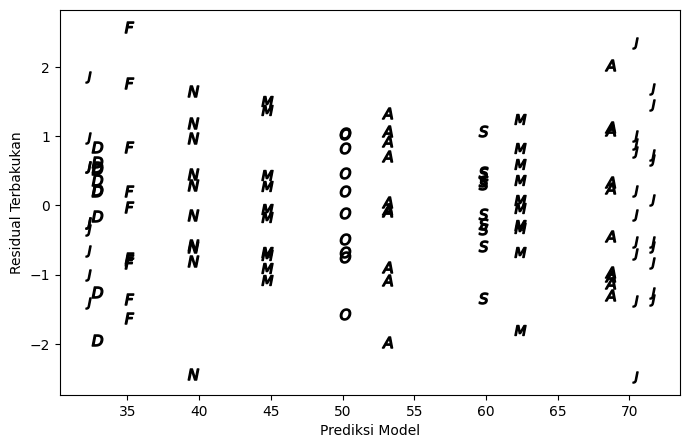

In [78]:
# membuat plot fittedvalues dengan residual terbakukan dengan simbol bulan
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
  plt.plot(musiman.fittedvalues.values[i],
           std_resid[i], marker=mapping[i%12+1],
           color='black', markersize=8)
plt.xlabel('Prediksi Model'),plt.ylabel('Residual Terbakukan')
plt.show()

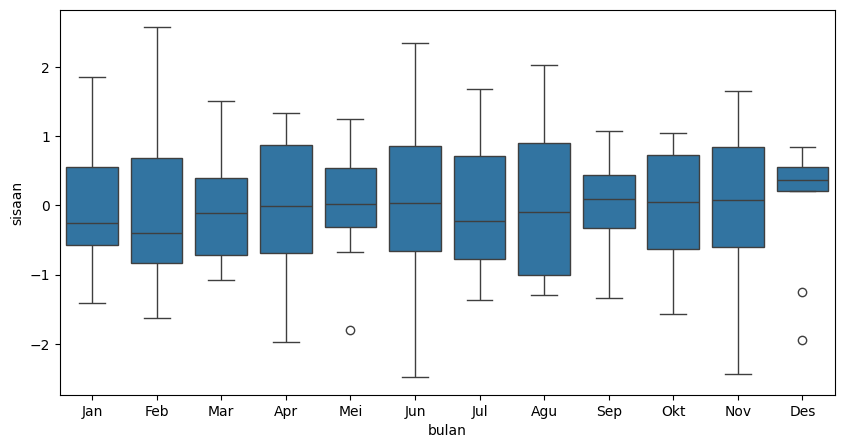

In [79]:
#membuat list daftar bulan
bulan=['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']*10

#membuat dataframe untuk mengidentifikasi sisaan dan periode bulannya
box_sisaan=pd.DataFrame(zip(bulan[:-1], std_resid),
columns=['bulan','sisaan'])

#membuat boxplot per buln
plt.figure(figsize=(10,5))
sns.boxplot(x='bulan',y='sisaan',data=box_sisaan)
plt.show()

##**Bagaimana interpretasi Anda terhadap tiga plot di atas?**

1. **Plot Residual Terbakukan vs Waktu** : Plot ini menampilkan sebaran sisaan terbakukan dari waktu ke waktu ($t = 1$ hingga $120$) dengan penanda inisial bulan. Sisaan tersebar secara acak di sekitar garis $0$, berada dalam rentang $-2$ hingga $+2$ (hampir tidak ada yang melebihi $\pm 3$), serta tidak membentuk pola tren naik, turun, atau siklis tertentu. Asumsi independensi (*non-autokorelasi*) terpenuhi. Sisaan bersifat acak (*white noise*) sepanjang periode waktu pengamatan.
2. **Plot Residual Terbakukan vs Prediksi Model** : Titik-titik sisaan terkelompok secara vertikal sesuai nilai prediksi bulanannya (karena hanya ada 12 nilai prediksi unik dari variabel *dummy* musiman). Sebaran sisaan di setiap kelompok prediksi terdistribusi seimbang di atas dan di bawah angka $0$ dengan rentang vertikal yang relatif sama lebar. Asumsi homoskedastisitas dan linearitas terpenuhi. Varians dari kesalahan bersifat konstan pada setiap tingkat nilai prediksi, dan tidak ada struktur eror yang tertinggal.
3. **Boxplot Sisaan per Bulan** : Menunjukkan distribusi sisaan khusus untuk tiap bulan (Jan–Des). Median tiap bulan berada di sekitar garis $0$, lebar kotak (IQR) relatif seragam, dan hanya terdapat sangat sedikit pencilan (*outliers*) minor pada bulan Mei dan Desember. Efek musiman berhasil dimodelkan secara sempurna. Tidak ada bulan tertentu yang memiliki bias sistematis (overestimasi/underestimasi) atau varians yang jauh berbeda dibanding bulan lainnya.


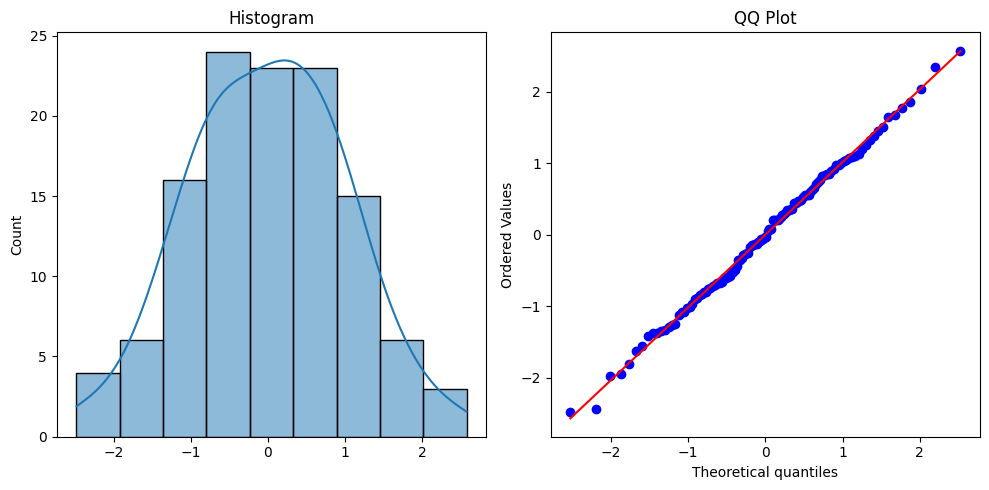

In [80]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(std_resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(std_resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

Berdasarkan plot-plot tersebut apakah dapat dikatakan bahwa model yang dipaskan sudah tepat?

Hitunglah statistik uji untuk mengecek asumsi model

### **1. Uji Asumsi Normalitas Secara Visual**
Ya, model yang digunakan sudah sangat tepat karena:

- **Histogram:** Bentuk distribusinya simetris dan membentuk kurva lonceng
  (*bell-shaped curve*) yang terpusat di sekitar angka 0.
- **QQ Plot:** Titik-titik sampel (biru) menempel sangat rapat pada garis
  acuan diagonal (merah), dari kuantil bawah hingga kuantil atas, tanpa
  adanya penyimpangan yang signifikan.

Kedua plot ini mengonfirmasi bahwa asumsi normalitas sisaan terpenuhi dengan
sangat baik, sehingga model regresi musiman tersebut tergolong valid.


### **2. Nilai Statistik Uji Asumsi Model (Uji Formal)**
Berdasarkan luaran ringkasan model OLS *Regression Results* yang telah kita
peroleh pada langkah sebelumnya (`musiman.summary()`), nilai-nilai statistik
uji untuk mengecek asumsi-asumsi model adalah sebagai berikut.

#### a. Uji Asumsi Normalitas Residual – Uji Omnibus

- **Statistik Uji (Omnibus Value):** 0,148
- **p-value (Prob(Omnibus)):** 0,929
- **Kesimpulan:** Karena $p\text{-value} = 0,929 > 0,05$, maka gagal menolak
$H_0$. Dengan demikian, residual/sisaan berdistribusi normal.

#### b. Uji Jarque-Bera (JB Test)

- **Statistik Uji (JB Value) :** 0,323
- **p-value (Prob(JB)):** 0,851
- **Skewness:** −0,003 (mendekati 0, menunjukkan distribusi sangat simetris)
- **Kurtosis:** 2,746 (mendekati 3, sesuai dengan kriteria distribusi normal)

- **Kesimpulan:** Karena $p\text{-value} = 0,851 > 0,05$, maka gagal menolak
$H_0$. Dengan demikian, residual/sisaan dapat dianggap berdistribusi normal.

#### c. Uji Asumsi Non-Autokorelasi (Independensi Residual)

- **Statistik Uji Durbin-Watson (DW):** 2,383

- **Kesimpulan:** Nilai Durbin-Watson sebesar 2,383 berada cukup dekat dengan
angka 2 dan masih berada dalam rentang yang umumnya dianggap aman
(1,5–2,5). Hal ini mengindikasikan bahwa tidak terdapat masalah
autokorelasi pada sisaan model.

In [81]:
# hitung statistik uji untuk mengecek asumsi model tanpa intersep

In [82]:
# pengepasan model regresi dengan intersep
musiman_int=sm.OLS(df_seasonal["Value"],sm.add_constant(musim.iloc[:,1:])).fit()

In [83]:
print(musiman_int.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       0.983
Model:                            OLS   Adj. R-squared:                  0.981
Method:                 Least Squares   F-statistic:                     570.8
Date:                Sat, 05 Sep 2026   Prob (F-statistic):           2.89e-90
Time:                        16:49:55   Log-Likelihood:                -244.85
No. Observations:                 120   AIC:                             513.7
Df Residuals:                     108   BIC:                             547.2
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         32.2583      0.621     51.981      0.0

Perhatikan hasil pengepasan model dengan intersep. Bandingkan hasilnya dengan pengepasan tanpa intersep. Bagaimana interpretasi model dengan intersep dibandingkan model tanpa intersep? Jelaskan cara memaknai nilai koefisien regresi yang diperoleh!

Apakah model dengan intersep sudah memenuhi asumsi regresi?

### **1. Perbandingan dan Perbedaan Interpretasi Model**

Secara keseluruhan, **performa kedua model identik**, dengan nilai
$R^2 = 0,983$, *F-statistic* = 570,8, AIC = 513,7, dan
*Log-Likelihood* = −244,85. Nilai-nilai tersebut sama persis pada kedua
model.

Perbedaan utama kedua model terletak pada **titik acuan (*baseline*) dalam
interpretasi koefisien**.

#### a. Model Tanpa Intersep

Model tanpa intersep menggunakan **12 dummy variable**, yaitu Januari hingga
Desember.

- Koefisien masing-masing bulan secara langsung menunjukkan **rata-rata nilai
  variabel respon (`Value`) pada bulan tersebut**.
- Tidak terdapat kategori bulan yang dijadikan sebagai *reference level*
  karena model tidak memiliki intersep.

#### b. Model Dengan Intersep

Model dengan intersep menggunakan **intersep (`const`) dan 11 dummy variable**.

- Januari digunakan sebagai **kategori referensi (*reference level*)**.
- Koefisien masing-masing dummy bulan menunjukkan **selisih atau perbedaan
  rata-rata nilai `Value` dibandingkan dengan bulan Januari**.

---

### **2. Cara Memaknai Nilai Koefisien Regresi pada Model Dengan Intersep**

#### a. `const` (Intersep = 32,2583)

Nilai intersep sebesar **32,2583** menunjukkan rata-rata nilai variabel
respon (`Value`) pada bulan acuan, yaitu **Januari**.

Dengan demikian:

$$
\hat{Y}_{Januari} = 32,2583
$$

#### b. `Februari` (Koefisien = 2,8296)

Koefisien Februari sebesar **2,8296** menunjukkan bahwa rata-rata nilai
`Value` pada bulan Februari **lebih tinggi 2,2316 unit** dibandingkan
bulan Januari.

Rata-rata nilai Februari dapat dihitung sebagai:

$$
\hat{Y}_{Februari}
=
29,2583 + 2,2316
=
31,4899
$$

#### c. `Juli` (Koefisien = 45,2858)

Koefisien Juli sebesar **45,2858** menunjukkan bahwa rata-rata nilai
`Value` pada bulan Juli **lebih tinggi 45,2858 unit** dibandingkan
bulan Januari.

Rata-rata nilai Juli adalah:

$$
\hat{Y}_{Juli}
=
29,2583 + 45,2858
=
74,5441
$$

Dengan demikian, bulan Juli memiliki **rata-rata nilai tertinggi**
dibandingkan bulan Januari berdasarkan model tersebut.

#### d. `Desember` (Koefisien = 2,0021)

Koefisien Desember sebesar **2,0021** menunjukkan bahwa rata-rata nilai
`Value` pada bulan Desember **lebih tinggi 2,0021 unit** dibandingkan
bulan Januari.

Rata-rata nilai Desember adalah:

$$
\hat{Y}_{Desember}
=
29,2583 + 2,0021
=
31,2604
$$

### Catatan

Seluruh koefisien dummy bulan bernilai positif dan signifikan secara
statistik dengan **$p\text{-value} < 0,05$**. Hal ini menunjukkan bahwa
rata-rata nilai `Value` pada bulan Februari hingga Desember secara
statistik lebih tinggi dibandingkan dengan bulan Januari.

---

### **3. Apakah Model Dengan Intersep Sudah Memenuhi Asumsi Regresi?**

**Ya, berdasarkan hasil pengujian diagnostik, model dengan intersep telah
memenuhi asumsi regresi yang diuji.**

Nilai-nilai diagnostik residual pada model dengan intersep sama dengan
model tanpa intersep, yaitu sebagai berikut.

#### a. Normalitas Residual

Hasil pengujian menunjukkan:

- **Prob(Omnibus) = 0,929 > 0,05**
- **Prob(Jarque-Bera) = 0,851 > 0,05**
- **Skewness = −0,003**, mendekati 0
- **Kurtosis = 2,746**, mendekati 3

Hipotesis yang digunakan:

$H_0$: Residual berdistribusi normal.

$H_1$: Residual tidak berdistribusi normal.

Karena nilai *p-value* pada uji Omnibus dan Jarque-Bera lebih besar dari
0,05, maka $H_0$ gagal ditolak.

**Kesimpulan:** Tidak terdapat bukti yang cukup untuk menyatakan bahwa
residual tidak berdistribusi normal. Dengan demikian, **asumsi normalitas
residual terpenuhi**.

#### b. Independensi Residual (Non-Autokorelasi)

Hasil pengujian Durbin-Watson menunjukkan:

- **Durbin-Watson = 2,383**

Nilai tersebut cukup dekat dengan angka 2 dan berada dalam kisaran
1,5–2,5 yang digunakan sebagai indikasi tidak adanya autokorelasi.

**Kesimpulan:** Tidak terdapat indikasi autokorelasi sistematis pada
residual, sehingga **asumsi independensi residual terpenuhi**.

---

### **4. Kesimpulan**

Berdasarkan perbandingan kedua model, model tanpa intersep dan model dengan
intersep menghasilkan ukuran kecocokan model yang identik. Perbedaan utama
terletak pada cara interpretasi koefisien.

Pada **model tanpa intersep**, koefisien masing-masing dummy bulan
menunjukkan rata-rata nilai `Value` pada bulan tersebut secara langsung.
Sedangkan pada **model dengan intersep**, koefisien dummy menunjukkan
perbedaan rata-rata nilai terhadap bulan Januari sebagai kategori referensi.

Model dengan intersep juga memenuhi asumsi **normalitas residual** dan
**non-autokorelasi** berdasarkan hasil pengujian yang dilakukan. Oleh karena
itu, model dapat digunakan untuk menginterpretasikan pola musiman pada
variabel `Value`.

In [84]:
# uji asumsi model dengan intersep

## Kecenderungan Linear dan Musiman

In [85]:
# Parameter
np.random.seed(1002)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 4.5, 14 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=2, size=n)

# Gabungan semua komponen
series = trend + seasonality + noise


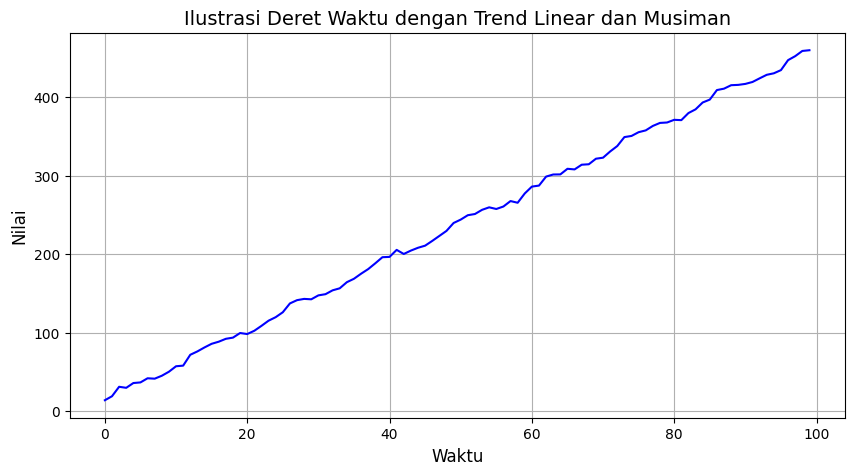

In [86]:
plt.figure(figsize=(10, 5))
plt.plot(x, series, color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman', fontsize=14)
plt.grid()
plt.show()

Untuk deret tersebut, dibutuhkan model yang mampu menangkap kecenderungan linear (tren) sekaligus kecenderungan musiman dalam deret. Salah satu model sederhana yang dapat digunakan adalah model regresi linear dengan variabel musiman.

#### **1. Analisis Komponen Deret Waktu**

Data tersebut merupakan gabungan dari dua komponen utama, yaitu komponen
tren dan komponen musiman.

##### a. Komponen Tren Linear (*Linear Trend*)

Terlihat bahwa garis utama data secara keseluruhan **terus mengalami
peningkatan secara relatif konstan**, dari nilai sekitar 10 pada $t = 0$
hingga mencapai nilai di atas 250 pada $t = 100$.

Hal ini menunjukkan adanya **kecenderungan peningkatan jangka panjang yang
bersifat linear**. Dengan kata lain, seiring bertambahnya waktu, nilai
variabel cenderung meningkat.

##### b. Komponen Musiman (*Seasonal Component*)

Di sepanjang garis tren yang meningkat tersebut terdapat **fluktuasi atau
gelombang naik-turun yang teratur dan berulang pada interval waktu
tertentu**.

Amplitudo atau tinggi fluktuasi terlihat relatif konstan sepanjang periode
pengamatan. Hal ini menunjukkan adanya **pola musiman yang stabil**, yaitu
perubahan nilai yang berulang secara sistematis pada periode tertentu.

Dengan demikian, deret waktu tersebut dapat dikatakan memiliki **komponen
tren linear dan komponen musiman dengan amplitudo yang relatif konstan**.

---

#### **2. Formulasi Model Regresi**

Untuk memodelkan deret waktu tersebut, komponen tren linear dapat
digabungkan dengan variabel *dummy* untuk menangkap pengaruh musiman.

##### Bentuk Umum Persamaan Model Aditif

$$
Y_t
=
\beta_0
+
\beta_1 t
+
\sum_{i=1}^{s-1}\gamma_i S_{it}
+
\varepsilon_t
$$

##### **Keterangan**

- **$Y_t$**: Nilai variabel respon pada waktu ke-$t$.
- **$\beta_0$**: Intersep, yaitu nilai dasar atau nilai harapan $Y_t$ ketika
  $t = 0$ dan berada pada periode musiman acuan.
- **$\beta_1$**: Koefisien tren linear atau *slope*, yang menunjukkan
  perubahan rata-rata nilai $Y_t$ untuk setiap kenaikan satu satuan waktu.
- **$t$**: Variabel waktu yang digunakan untuk menangkap komponen tren.
- **$S_{it}$**: Variabel *dummy* untuk periode musiman ke-$i$ pada waktu
  ke-$t$.
- **$\gamma_i$**: Koefisien musiman yang menunjukkan perbedaan rata-rata
  nilai $Y_t$ pada periode musiman ke-$i$ dibandingkan dengan periode
  musiman acuan.
- **$s$**: Jumlah periode dalam satu siklus musiman.
- **$\varepsilon_t$**: Sisaan (*error*) atau gangguan acak pada waktu ke-$t$.

##### **Interpretasi Model**

Model tersebut mengasumsikan bahwa nilai deret waktu merupakan hasil
penjumlahan dari:

$$
\text{Nilai Deret Waktu}
=
\text{Tren Linear}
+
\text{Komponen Musiman}
+
\text{Sisaan}
$$

Dengan demikian, model dapat digunakan untuk menjelaskan **kenaikan
jangka panjang akibat tren** sekaligus **fluktuasi yang berulang akibat
pola musiman**.

In [87]:
# mengubah data menjadi format dataframe
df_mix = pd.DataFrame(series, columns=['Value'])

# mengekstrak komponen musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
season= Seasonality(12, initial_period=1).in_sample(df_mix.index)
season.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [88]:
season['period']=x

model_mix=sm.OLS(series,season).fit()

In [89]:
print(model_mix.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.417e+04
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          2.90e-154
Time:                        16:49:55   Log-Likelihood:                -205.62
No. Observations:                 100   AIC:                             437.2
Df Residuals:                      87   BIC:                             471.1
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari       14.4589      0.756     19.134      0.0

Bagaimana cara menginterpretasikan nilai koefisien regresi yang diperoleh dalam model regresi tersebut?

### **Interpretasi Koefisien Regresi**

Berdasarkan luaran **OLS Regression Results** untuk model regresi yang
menggabungkan komponen **tren linear** dan **variabel musiman tanpa
intersep**, interpretasi nilai koefisien regresinya adalah sebagai berikut.

#### **1. Koefisien Komponen Tren Linear (`period`)**

- **Nilai koefisien (*coef*) = 2,5002**

Nilai koefisien `period` sebesar 2,5002 menunjukkan besarnya perubahan
rata-rata variabel respon `y` untuk setiap kenaikan satu satuan waktu,
dengan asumsi efek musiman tetap.

**Interpretasi:**

Setiap bertambahnya **1 periode waktu**, nilai `y` diperkirakan mengalami
**peningkatan sebesar 2,5002 unit** dengan efek musiman tetap.

Koefisien tren tersebut signifikan secara statistik karena memiliki
$p\text{-value} < 0,05$.

Dengan demikian, terdapat **tren peningkatan yang signifikan** pada
variabel `y` sepanjang periode pengamatan.

---

#### **2. Koefisien Komponen Musiman (Januari–Desember)**

Karena model tidak menggunakan intersep (`const`), maka ke-12 variabel
dummy bulan dimasukkan secara langsung ke dalam model.

Koefisien masing-masing bulan menunjukkan **nilai dasar (*baseline/level*)
untuk bulan tersebut ketika `period = 0`**.

##### a. Januari

Koefisien Januari sebesar **12,4589**.

Artinya, ketika `period = 0` dan periode tersebut merupakan bulan Januari,
nilai `y` yang diperkirakan adalah sebesar **12,4589 unit**.

##### b. Maret

Koefisien Maret sebesar **17,3331**.

Artinya, ketika `period = 0` dan periode tersebut merupakan bulan Maret,
nilai dasar `y` yang diperkirakan adalah sebesar **17,3331 unit**.

Dibandingkan dengan bulan lainnya, Maret memiliki **level musiman
tertinggi** berdasarkan koefisien model.

##### c. Oktober

Koefisien Oktober sebesar **7,0267**.

Artinya, ketika `period = 0` dan periode tersebut merupakan bulan Oktober,
nilai dasar `y` yang diperkirakan adalah sebesar **7,0267 unit**.

Oktober memiliki **level musiman terendah** berdasarkan koefisien model.

##### d. Signifikansi Koefisien Musiman

Seluruh koefisien dummy bulan memiliki $p\text{-value} < 0,05$.

Dengan demikian, masing-masing komponen musiman tersebut **signifikan
secara statistik** dalam menjelaskan variasi nilai `y` setelah
memperhitungkan komponen tren linear.

---

###**3. Persamaan Regresi**

Karena model menggunakan tren linear dan 12 dummy bulan tanpa intersep,
persamaan regresinya dapat dituliskan secara umum sebagai:

$$
\hat{y}_t
=
\beta_1 \text{period}_t
+
\sum_{i=1}^{12}\gamma_i S_{it}
$$

Berdasarkan hasil estimasi, koefisien tren linear adalah 2,5002, sehingga
persamaan dapat ditulis sebagai:

$$
\hat{y}_t
=
2,5002 \times \text{period}_t
+
\text{Efek Bulan}_i
$$

Dengan demikian, nilai prediksi `y` diperoleh dari penjumlahan antara
**efek tren pada periode tertentu** dan **efek musiman bulan yang
bersangkutan**.

---

### **4. Contoh Perhitungan Prediksi**

Sebagai contoh, misalkan ingin memprediksi nilai `y` pada bulan **Maret**
ketika `period = 15`.

Koefisien Maret = 17,3331 dan koefisien `period` = 2,5002.

Maka:

$$
\hat{y}
=
17,3331
+
(2,5002 \times 15)
$$

$$
\hat{y}
=
17,3331
+
37,5030
$$

$$
\hat{y}
=
54,8361
$$

Jadi, nilai `y` yang diprediksi pada bulan Maret ketika
`period = 15` adalah sekitar **54,8361 unit**.

---

### **5. Kesimpulan**

Berdasarkan hasil estimasi model, terdapat **tren peningkatan yang
signifikan** pada variabel `y`, dengan laju peningkatan rata-rata sebesar
**2,5002 unit untuk setiap kenaikan satu periode waktu**.

Selain tren linear, terdapat pula **pola musiman bulanan yang signifikan**.
Berdasarkan nilai koefisien musiman, bulan **Maret memiliki level dasar
tertinggi**, yaitu 17,3331, sedangkan bulan **Oktober memiliki level dasar
terendah**, yaitu 7,0267.

Nilai $R^2 = 0,999$ menunjukkan bahwa model memiliki kemampuan yang sangat
tinggi dalam menjelaskan variasi nilai `y` pada data pengamatan.

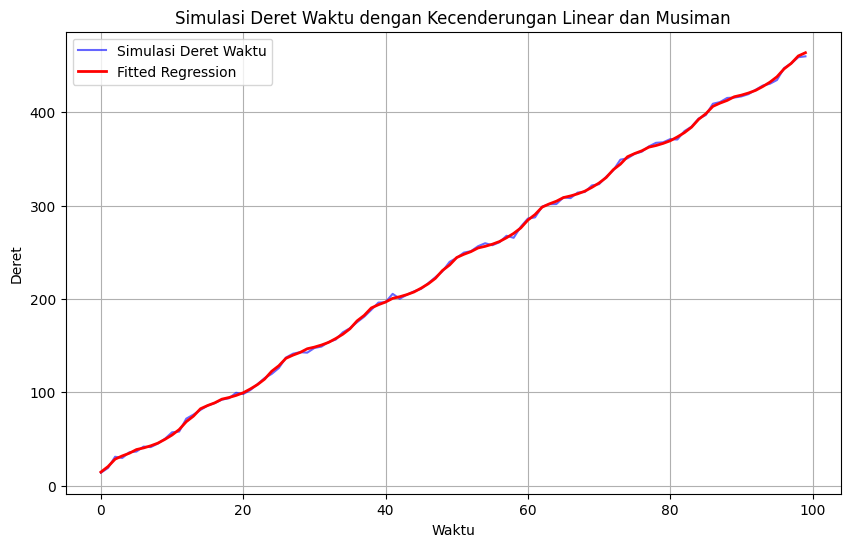

In [90]:
# Prediksi menggunakan model yang sudah dilatih
pred_mix = model_mix.predict(season)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(x, series, label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(x, pred_mix, label='Fitted Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Linear dan Musiman')
plt.xlabel('Waktu')
plt.ylabel('Deret')
plt.legend()
plt.grid(True)
plt.show()

**Lakukan pengecekan asumsi model! Jelaskan apakah hasil menunjukkan ada pelanggaran asumsi dalam model!**

### **1. Pengecekan Asumsi-Asumsi Model**
##### a. Spesifikasi Model dan *Goodness of Fit*

Garis prediksi merah terlihat sangat berimpit dengan pola data/simulasi biru sepanjang periode pengamatan $t = 0$ hingga $t = 100$. Nilai $R^2 = 0,999$ menunjukkan bahwa model yang menggabungkan **tren linear dan variabel musiman bulanan** mampu menjelaskan sekitar **99,9% variasi data**.

Dengan demikian, model memiliki kemampuan yang sangat baik dalam mengikuti pola data.

##### b. Normalitas Sisaan

Normalitas sisaan dapat dilihat dari hasil uji Omnibus dan Jarque-Bera:

- **Prob(Omnibus) = 0,946 > 0,05**
- **Prob(JB) = 0,909 > 0,05**
- **Skewness = 0,077**, mendekati 0
- **Kurtosis = 2,851**, mendekati 3

Karena nilai probabilitas kedua pengujian lebih besar dari 0,05, maka **tidak terdapat bukti yang cukup untuk menolak asumsi normalitas sisaan**.

Dengan demikian, sisaan dapat dianggap berdistribusi normal.

##### c. Independensi Sisaan / Autokorelasi

Nilai **Durbin-Watson = 2,362**. Nilai tersebut relatif dekat dengan angka 2, yang secara umum menunjukkan bahwa autokorelasi orde pertama tidak tampak kuat.

Namun, **Durbin-Watson sebaiknya tidak digunakan sendirian** untuk menyimpulkan tidak adanya autokorelasi. Untuk memastikan, pengujian dapat dilengkapi dengan **uji Ljung-Box atau Breusch-Godfrey**.

Jika hasil uji tersebut memiliki $p\text{-value} > 0,05$, maka dapat disimpulkan bahwa **tidak terdapat bukti autokorelasi yang signifikan pada sisaan**.

##### d. Homoskedastisitas

Secara visual, jarak antara nilai aktual dan nilai prediksi terlihat relatif stabil sepanjang periode pengamatan dan tidak menunjukkan pola kipas (*funnel*) yang jelas. Hal ini memberikan indikasi bahwa varians sisaan relatif konstan.

Untuk memastikan secara statistik, sebaiknya dilakukan **uji Breusch-Pagan**. Jika diperoleh $p\text{-value} > 0,05$, maka asumsi homoskedastisitas terpenuhi.


#### **2. Kesimpulan: Apakah Ada Pelanggaran Asumsi?**

Berdasarkan hasil pemeriksaan, model **tren linear + variabel musiman bulanan** menunjukkan kecocokan yang sangat baik terhadap data dengan $R^2 = 0,999$.

Sisaan juga **tidak menunjukkan indikasi kuat penyimpangan dari normalitas**, berdasarkan nilai Prob(Omnibus) dan Prob(JB) yang lebih besar dari 0,05.

Nilai Durbin-Watson sebesar **2,362** menunjukkan bahwa autokorelasi orde pertama tidak tampak kuat, tetapi kesimpulan akhir mengenai independensi sisaan sebaiknya dikonfirmasi menggunakan **uji Ljung-Box atau Breusch-Godfrey**.

Demikian pula, indikasi visual homoskedastisitas sebaiknya dikonfirmasi menggunakan **uji Breusch-Pagan**.

> **Kesimpulan:** Berdasarkan hasil yang tersedia, **belum ditemukan indikasi kuat adanya pelanggaran asumsi model**. Namun, untuk menyatakan bahwa seluruh asumsi benar-benar terpenuhi, diperlukan konfirmasi melalui pengujian statistik tambahan untuk autokorelasi dan heteroskedastisitas.

In [91]:
# uji asumsi model

Saat melihat plot dari suatu deret, terkadang kita tidak yakin komponen apa saja yang ada dalam deret. Misalkan, apakah deret tidak memuat tren? apakah ada tren? apakah ada komponen musiman? Untuk memastikan komponen apa saja yang ada dalam suatu deret, dapat dilakukan dengan dekomposisi deret. Dekomposisi deret bertujuan menguraikan deret menjadi 3 komponen, yaitu tren, musiman, dan noise.

In [92]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['Value'], model='additive', period=12)

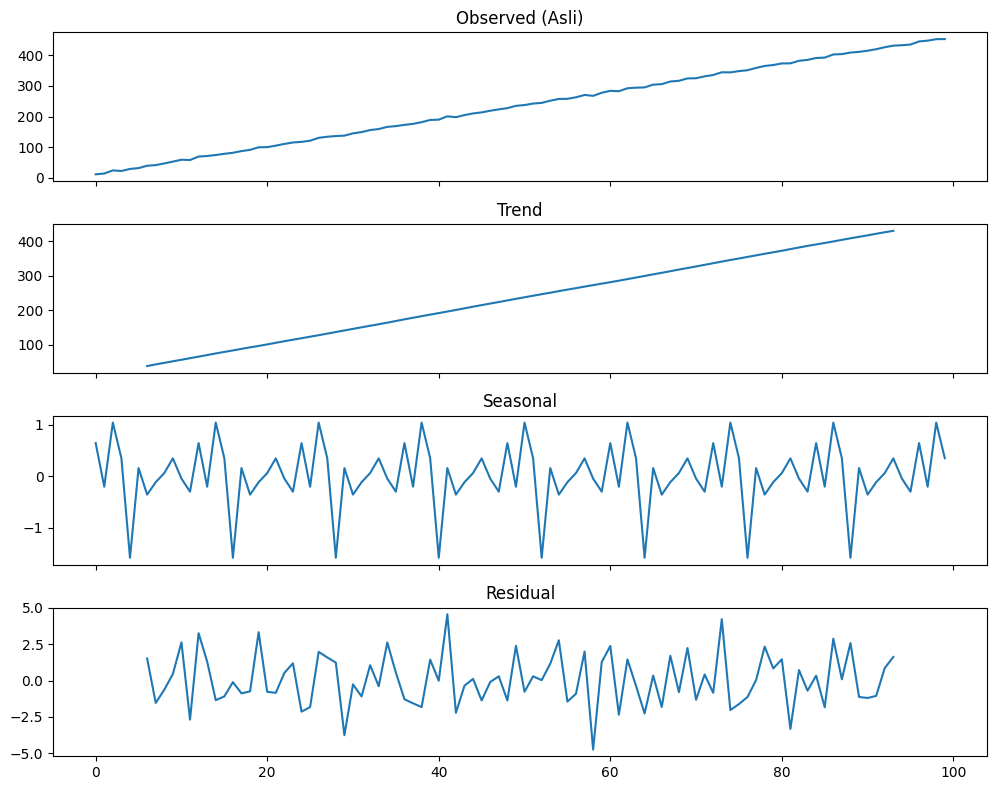

In [93]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

**Bagaimana interpretasi hasil dekomposisi deret tersebut?**

Berdasarkan hasil plot dekomposisi deret waktu (*time series decomposition*) di atas, berikut adalah interpretasi untuk masing-masing komponennya:
1. Komponen Observed (Data Asli) : Plot paling atas menunjukkan data observasi asli yang merupakan hasil penggabungan dari komponen tren, musiman, dan sisaan. Terlihat pola pertumbuhan naik secara konsisten yang diiringi oleh riak-riak fluktuasi kecil di sepanjang garisnya.
2. Komponen Trend (Tren) : Plot kedua menampilkan komponen tren jangka panjang. Garis bergerak lurus naik secara konstan dari nilai sekitar $25$ hingga mendekati $250$. Ini mengonfirmasi adanya tren linear positif yang sangat kuat pada data.
3. Komponen Seasonal (Musiman) : Plot ketiga menunjukkan komponen musiman yang berhasil dipisahkan.Pola gelombang berulang secara teratur dengan siklus yang identik sepanjang periode waktu.Amplitudo atau besar fluktuasinya tetap (berada di rentang $-1.5$ hingga $+1.0$), yang menandakan bahwa komponen musiman ini bersifat aditif (additive seasonality).
4. Komponen Residual (Sisaan/*Noise*) : Plot paling bawah menampilkan sisaan acak setelah tren dan musiman dikeluarkan dari data asli.
*   Sisaan bergerak naik-turun secara acak di sekitar angka $0$ (rentang $-4.5$ hingga $+4.5$).
*   Tidak terlihat adanya pola tren atau musiman yang tersisa pada plot ini, yang menandakan bahwa dekomposisi berhasil memisahkan komponen utama data dengan baik.

Kesimpulan Utama:Hasil dekomposisi membuktikan bahwa deret waktu tersebut dibentuk oleh kombinasi tren linear positif yang dominan dan pola musiman aditif yang stabil, dengan variasi acak (noise) yang relatif kecil.

In [94]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear dan musiman
from statsmodels.tsa.seasonal import seasonal_decompose
result_mix = seasonal_decompose(df_mix['Value'], model='additive', period=12)

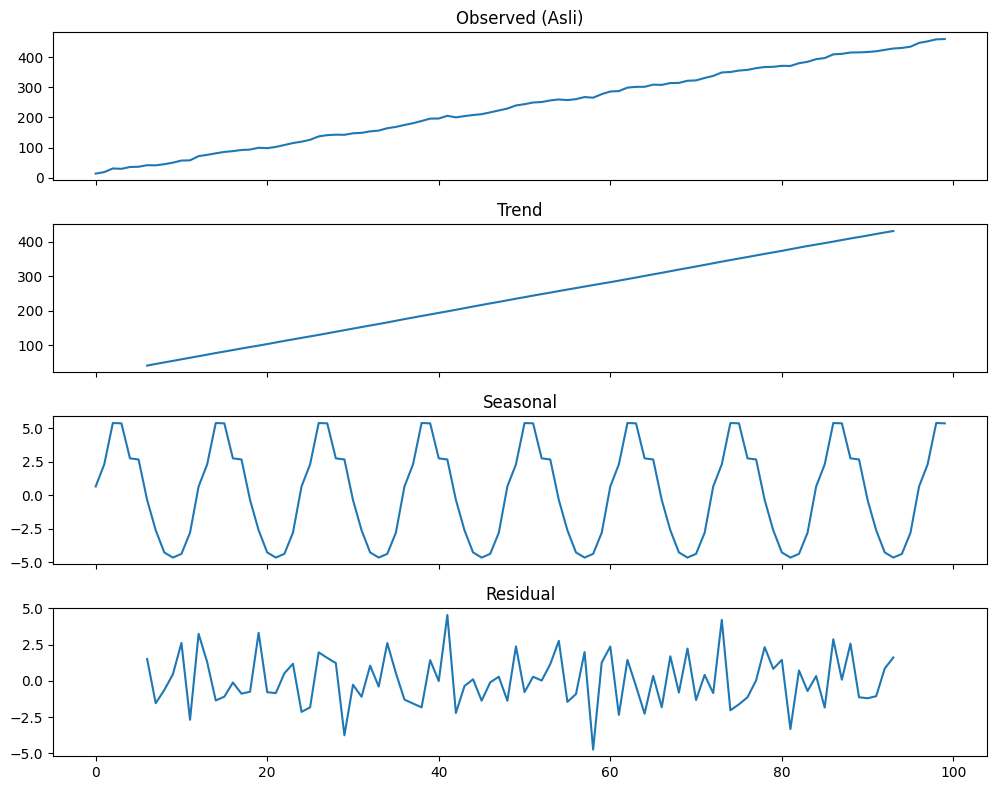

In [95]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result_mix.observed.plot(ax=axes[0], title='Observed (Asli)')
result_mix.trend.plot(ax=axes[1], title='Trend')
result_mix.seasonal.plot(ax=axes[2], title='Seasonal')
result_mix.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()


**Bagaimana interpretasi hasil dekomposisi deret tersebut?**


*   Observed (Data Asli): Menunjukkan kombinasi tren peningkatan jangka panjang yang stabil diiringi riak fluktuasi musiman yang berulang teratur dari waktu ke waktu.
*   Trend (Tren): Garis tren naik secara konsisten dan linear dari nilai sekitar $25$ hingga mendekati $250$, menegaskan adanya tren linear positif yang kuat.
*   Seasonal (Musiman): Pola musiman membentuk gelombang yang sangat simetris dan teratur dengan tinggi puncak di sekitar $+5,0$ dan lembah di sekitar $-4,5$. Amplitudo gelombang ini konstan sepanjang $t = 0$ hingga $100$.
*   Residual (Sisaan): Sisaan tersebar secara acak di sekitar nilai $0$ (berada dalam rentang $-4,5$ hingga $+4,5$) tanpa membentuk pola sistematis tertentu (white noise).


Ketika melakukan dekoposisi deret, perlu diperhatikan bahwa terdapat 2 jenis model untuk dekomposisi, yaitu model `Aditif` dan `multiplikatif`.

- Model `aditif` digunakan jika ragam deret relatif konstan atau kecil

- Model `multiplikatif` digunakan jika ragam deret besar

Pilihan Jenis Model Dekomposisi: Aditif vs Multiplikatif
<br> Berdasarkan penjelasan pada gambar dan karakteristik plot di atas:Model yang tepat digunakan adalah Model Aditif.</br>
<br>Alasan:
*   Ragam/Variabilitas Konstan: Tinggi atau amplitudo gelombang pada plot Seasonal dan plot Observed tidak membesar meskipun nilai trennya meningkat drastis (dari level 25 ke 250). Fluktuasinya tetap berada pada skala absolut yang sama (sekitar $\pm 5$).
*   Karakteristik Model Aditif: Sesuai dengan catatan pada gambar, model aditif digunakan ketika ragam deret relatif konstan. Pada model ini, hubungan antar komponen dinyatakan sebagai:$$Y_t = \text{Trend}_t + \text{Seasonal}_t + \text{Residual}_t$$
</br>



In [96]:
# ilustrasi untuk deret multiplikatif
# Parameter
np.random.seed(1002)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 2.05, 12 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 1+ 0.5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=0.2, size=n)

# Gabungan semua komponen
series_multi = trend*seasonality + noise

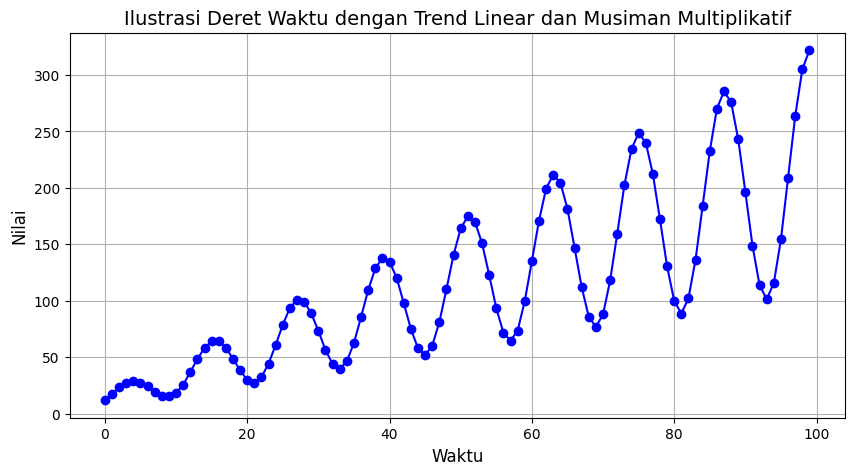

In [97]:
plt.figure(figsize=(10, 5))
plt.plot(x, series_multi, color='b', marker='o')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman Multiplikatif', fontsize=14)
plt.grid()
plt.show()

**Dekomposisi dengan model multiplikatif hanya bisa dilakukan untuk deret dengan nilai >0, sehingga jika deret memiliki nilai 0 atau negatif maka deret perlu ditransformasi.**

## 1. Ciri Utama Pola Multiplikatif

### a. Amplitudo Fluktuasi Membesar (*Increasing Variance*)

Perbedaan paling mencolok pada pola multiplikatif adalah **amplitudo atau lebar fluktuasi musiman yang semakin membesar** seiring bertambahnya waktu ($t$).

- Pada awal periode ($t = 0 - 20$), selisih antara puncak dan lembah relatif kecil, yaitu sekitar **15 hingga 60**.
- Pada akhir periode ($t = 80 - 100$), selisih antara puncak dan lembah menjadi jauh lebih besar, dengan nilai lembah sekitar **100** dan nilai puncak **melebihi 300**.

Hal tersebut menunjukkan bahwa **variabilitas data meningkat seiring meningkatnya level atau tren data**.

### b. Efek Proporsional terhadap Tren

Pada pola multiplikatif, variasi musiman tidak memiliki besar yang konstan. Sebaliknya, **besar fluktuasi musiman cenderung proporsional terhadap level data**.

Artinya, semakin tinggi nilai tren atau level deret waktu, semakin besar pula fluktuasi musimannya.

---

## 2. Formulasi Model Multiplikatif

Dalam model multiplikatif, komponen-komponen deret waktu saling **dikalikan**, sehingga secara umum dapat dituliskan sebagai:

$$
Y_t = T_t \times S_t \times R_t
$$

dengan:

- $Y_t$ = nilai aktual deret waktu pada periode $t$
- $T_t$ = komponen tren (*trend*)
- $S_t$ = komponen musiman (*seasonal*)
- $R_t$ = komponen sisaan (*residual/irregular*)

---

## 3. Penanganan Data dengan Transformasi Logaritma

Model multiplikatif umumnya digunakan ketika **varians atau amplitudo fluktuasi meningkat seiring dengan meningkatnya level data**.

Untuk melakukan analisis menggunakan pendekatan regresi linear, data dapat ditransformasikan menggunakan logaritma natural:

$$
\ln(Y_t)
=
\ln(T_t)
+
\ln(S_t)
+
\ln(R_t)
$$

Transformasi logaritma tersebut mengubah hubungan **multiplikatif menjadi aditif**, sehingga lebih mudah dianalisis menggunakan metode linear.

### Syarat Penting

Transformasi logaritma hanya dapat diterapkan secara langsung apabila seluruh nilai data memenuhi:

$$
Y_t > 0
$$

Jika terdapat nilai **0 atau negatif**, transformasi $\ln(Y_t)$ tidak dapat dilakukan secara langsung. Oleh karena itu, diperlukan penanganan terlebih dahulu sesuai karakteristik data.

> **Catatan:** Menambahkan konstanta ($Y_t+c$) bukan selalu pilihan terbaik, karena dapat mengubah interpretasi dan struktur data. Pemilihan transformasi sebaiknya disesuaikan dengan karakteristik deret waktu yang dianalisis.

In [98]:
#  Dekomposisi dengan model multiplikatif
# mengubah data menjadi format dataframe
df_multi = pd.DataFrame(series_multi, columns=['Value'])

from statsmodels.tsa.seasonal import seasonal_decompose
result_multi = seasonal_decompose(df_multi['Value'], model='multiplicative', period=12)

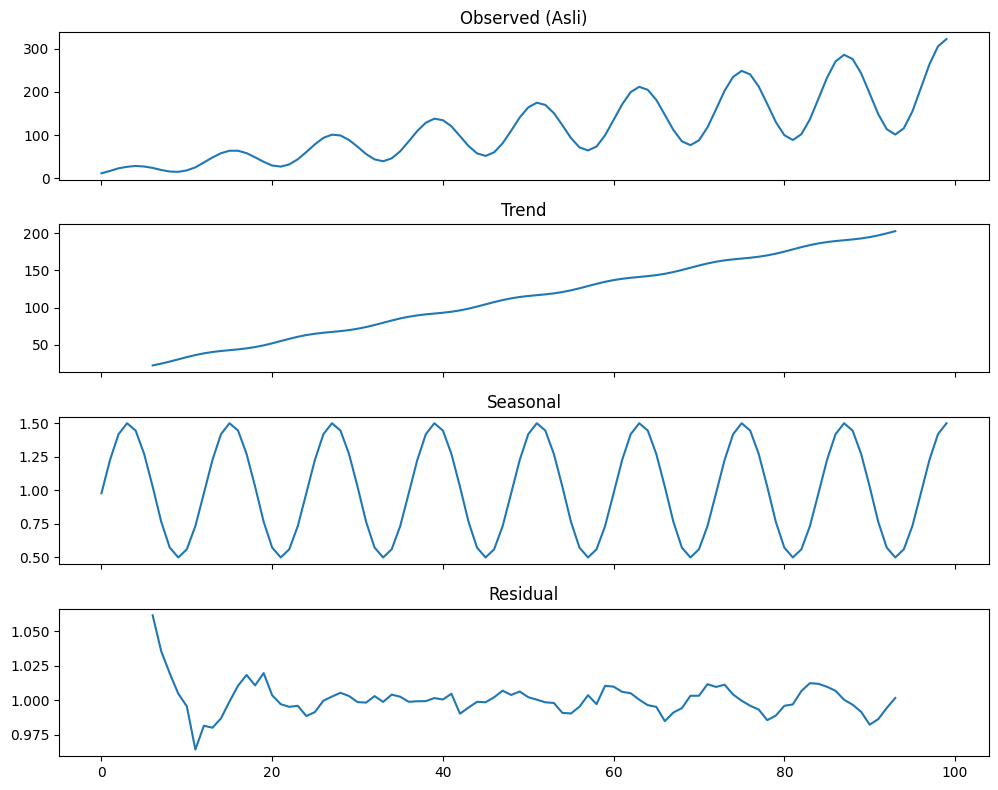

In [99]:
# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result_multi.observed.plot(ax=axes[0], title='Observed (Asli)')
result_multi.trend.plot(ax=axes[1], title='Trend')
result_multi.seasonal.plot(ax=axes[2], title='Seasonal')
result_multi.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

**Bagaimana Anda menginterpretasikan plot hasil dekomposisi tersebut?**

## Interpretasi Hasil Dekomposisi Multiplikatif

Berdasarkan plot hasil dekomposisi multiplikatif pada gambar di atas, interpretasi masing-masing komponen adalah sebagai berikut:

### 1. Observed (Data Asli)

Komponen **Observed** menunjukkan data aktual yang merupakan gabungan dari tren, pola musiman, dan variasi acak.

Terlihat bahwa data memiliki **tren yang meningkat** dan disertai fluktuasi musiman dengan amplitudo yang semakin besar seiring meningkatnya level data. Nilai data bergerak dari sekitar **0 hingga lebih dari 300**.

Pola tersebut menunjukkan bahwa variasi musiman cenderung **proporsional terhadap level data**, yang merupakan karakteristik dari pola multiplikatif.

### 2. Trend (Tren)

Komponen **Trend** menunjukkan kecenderungan jangka panjang dari deret waktu setelah pengaruh musiman dan variasi acak dipisahkan.

Pada plot, tren bergerak **meningkat secara konsisten**, dari sekitar **25 hingga 200**. Hal ini menunjukkan adanya **pertumbuhan jangka panjang yang relatif stabil** pada deret waktu.

Dengan kata lain, secara umum tingkat data mengalami peningkatan dari waktu ke waktu.

### 3. Seasonal (Musiman)

Komponen **Seasonal** menunjukkan pola berulang yang terjadi secara periodik. Dalam dekomposisi multiplikatif, komponen musiman dinyatakan sebagai **faktor pengali atau indeks musiman** yang berfluktuasi di sekitar angka **1,0**.

Pada hasil dekomposisi, faktor musiman berada pada kisaran sekitar **0,50 hingga 1,50**.

- **Puncak (*Peak*) = 1,50**

  Nilai 1,50 menunjukkan bahwa pada periode musiman tersebut, nilai observasi cenderung berada sekitar **50% lebih tinggi dibandingkan tingkat trennya**, dengan asumsi komponen lainnya mendekati 1.

- **Lembah (*Trough*) = 0,50**

  Nilai 0,50 menunjukkan bahwa pada periode tersebut, nilai observasi cenderung berada sekitar **50% lebih rendah dibandingkan tingkat trennya**, dengan asumsi komponen lainnya mendekati 1.

Dengan demikian, pola musiman menunjukkan adanya periode tertentu yang secara konsisten meningkatkan atau menurunkan nilai data secara **proporsional terhadap level tren**.

### 4. Residual (Sisaan)

Komponen **Residual** menunjukkan variasi yang tidak dapat dijelaskan oleh tren dan pola musiman.

Pada plot, residual berada sangat dekat dengan angka **1,0**, dengan sebagian besar nilai berada pada kisaran **0,975–1,025**, meskipun terdapat sedikit penyimpangan pada awal periode ($t < 10$).

Nilai residual yang mendekati 1 menunjukkan bahwa **variasi yang tersisa setelah komponen tren dan musiman dikeluarkan relatif kecil**. Artinya, sebagian besar pola data dapat dijelaskan oleh komponen tren dan musiman.

---

## Kesimpulan Utama

Berdasarkan hasil dekomposisi, deret waktu menunjukkan karakteristik **model multiplikatif**, yaitu:

$$
Y_t = T_t \times S_t \times R_t
$$

dengan:

- $Y_t$ = data aktual,
- $T_t$ = komponen tren,
- $S_t$ = komponen musiman, dan
- $R_t$ = komponen residual.

Karakteristik utama yang mendukung penggunaan model multiplikatif adalah **amplitudo fluktuasi musiman yang semakin besar seiring meningkatnya level atau tren data**.

Hasil dekomposisi juga menunjukkan bahwa **tren mengalami peningkatan secara konsisten**, pola musiman berulang dengan faktor pengali sekitar **0,50–1,50**, sedangkan residual relatif kecil dan berpusat di sekitar **1,0**.

Dengan demikian, pola deret waktu lebih tepat dijelaskan sebagai **kombinasi tren meningkat dan efek musiman yang bersifat proporsional terhadap level data**.

In [100]:
# Parameter
np.random.seed(1002)
n = 100  # Jumlah titik data
x = np.arange(n)

# Hanya noise acak tanpa trend atau musiman
noise = np.random.normal(loc=10, scale=2, size=n)  # Nilai acak sekitar 10

# Buat DataFrame untuk regresi
df = pd.DataFrame({'Time': x, 'Series': noise})
df['Time'] = pd.to_datetime(df['Time'], unit='D')  # Konversi ke format waktu
df.set_index('Time', inplace=True)

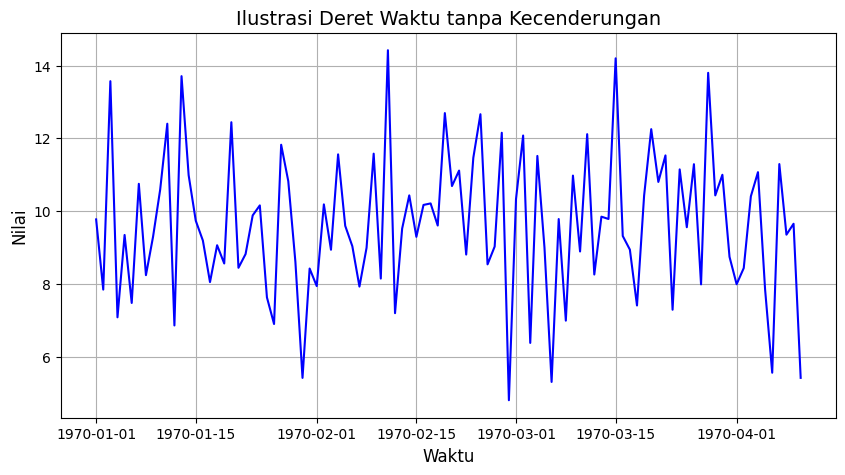

In [101]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Series'], color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu tanpa Kecenderungan', fontsize=14)
plt.grid()
plt.show()

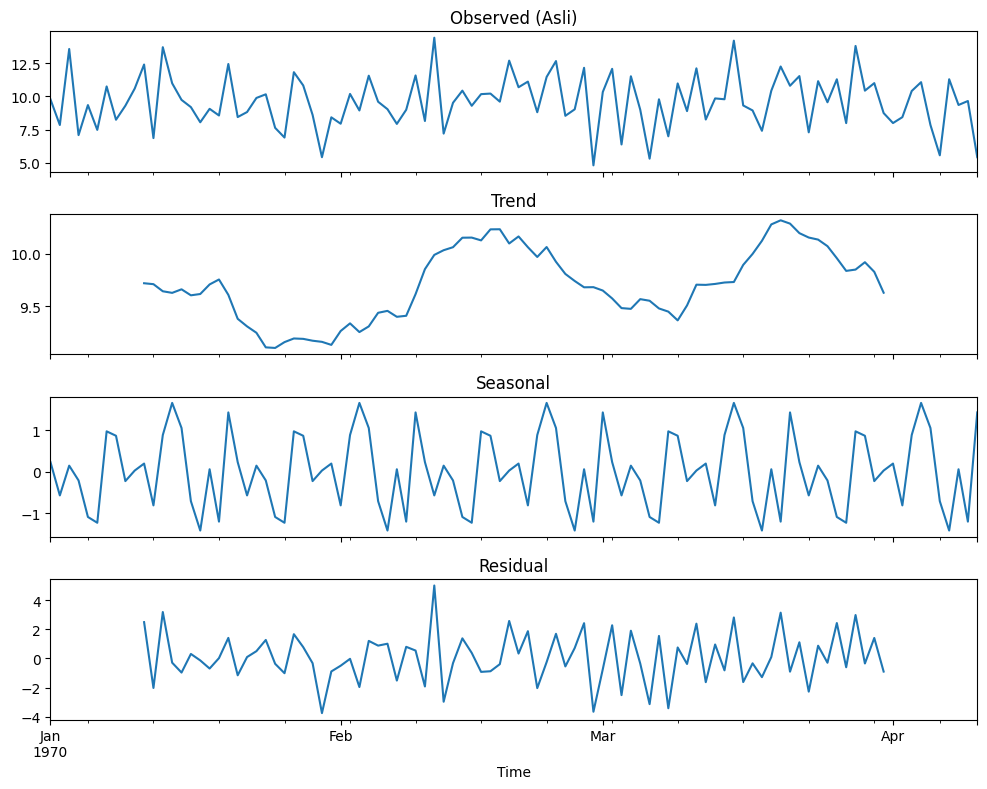

In [102]:
# Lakukan dekomposisi dengan model aditif
result = seasonal_decompose(df['Series'], model='additive', period=20)

# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

**Bagaimana interpretasi dari plot tersebut?**

Berdasarkan plot dekomposisi deret waktu di atas, berikut adalah interpretasi untuk tiap komponennya:

*   Observed (Data Asli):Menampilkan data harian (Januari–April 1970) yang sangat berfluktuasi secara dinamis dalam rentang nilai $5,0$ hingga $14,0$, tanpa adanya tren jangka panjang yang jelas.
*   Trend (Tren):Komponen tren bergerak secara non-linear (tidak membentuk garis lurus). Terlihat adanya fluktuasi jangka menengah—sempat turun ke titik terendah sekitar $9,1$ pada akhir Januari, lalu naik hingga puncaknya mendekati $10,3$ di pertengahan Februari dan pertengahan Maret, sebelum akhirnya kembali menurun di akhir Maret.
*   Seasonal (Musiman):Pola musiman berulang secara sangat teratur dengan siklus interval pendek (kemungkinan siklus mingguan/harian). Skala nilainya bergerak di sekitar angka $0$ (rentang $-1,5$ hingga $+1,7$), yang menandakan bahwa dekomposisi ini menggunakan Model Aditif.Amplitudo gelombangnya konstan dari awal hingga akhir periode.
*   Residual (Sisaan):Sisaan terdistribusi secara acak di sekitar nilai $0$ (sebagian besar berada pada rentang $-4$ hingga $+3$). Tidak terlihat adanya pola sistematis tersisa, meskipun terdapat satu lonjakan (spike) acak di atas $4,0$ pada pertengahan Februari.

Kesimpulan Utama : Deret waktu ini merupakan deret waktu stasioner dengan pola musiman aditif berfrekuensi tinggi (siklus pendek) yang dikombinasikan dengan tren non-linear/fleksibel yang mengalami fluktuasi jangka menengah.